# Ajuste de taxas de transfência não radiativa 

O sistema de EDO que contém os parâmetros de interesse é

\begin{equation}
\begin{aligned}
    \frac{dn_5}{dt}
    &=
    \sigma P F(t)\, n_4
    - W_{51} n_1 n_5
    - W_{52} n_2 n_5
    - k_{54} n_5 
    \\
    \frac{dn_2}{dt}
    &=
    W_{51} n_1 n_5
    - W_{52} n_2 n_5
    - k_{21} n_2 
    \\
    \frac{dn_3}{dt}
    &=
    W_{52} n_2 n_5
    - k_{31} n_3 
\end{aligned}
\end{equation}

Adimensionalizando a concentração por $n_1$ e o tempo por $2\pi/\omega = 1/f$, obtemos

\begin{aligned}
\frac{dx_5}{d\tau}
&=
\Pi F(\tau) x_4
- W'_{51} x_5
- W'_{52} x_2 x_5
- k'_{54} x_5
\\
\frac{dx_2}{d\tau}
&=
W'_{51} x_5
- W'_{52} x_2 x_5
- k'_{21} x_2
\\
\frac{dx_3}{d\tau}
&=
W'_{52} x_2 x_5
- k'_{31} x_3
\end{aligned},
onde 

### Dados experimentais

In [11]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares, curve_fit
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from treament_tcspc_data import fetch_data_filenames, extract_data_info_from_path, time_domain_visual_verification
# from snr_aux_functions import get_snr_db, plot_time_and_freq_domain

In [12]:
pd_list = np.load("phase_difference_list.npy") #obtained from https://github.com/habakukc22/many-particles-analysis-more-repetitions

In [13]:
pd_list.shape

(30, 26, 3)

(30, 26, 3)


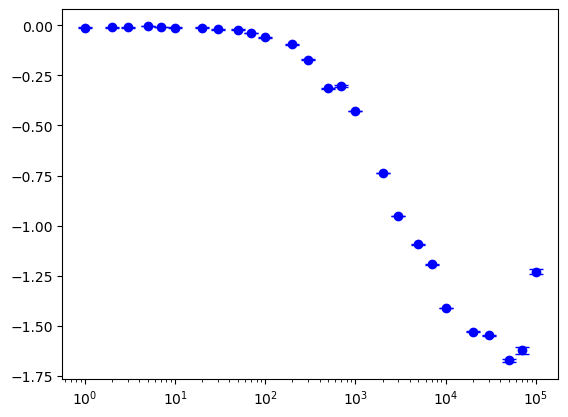

In [14]:
print(pd_list.shape)

for p_idx, p in enumerate(pd_list):
    if p_idx != 0: continue
    for step in p:
        # print(point)
        plt.errorbar(
            step[0], 
            step[1],
            yerr=step[2],
            fmt="o",
            capsize=5,
            color="blue"
            )
plt.xscale("log")
plt.show()

### Tentativa de parâmetros iniciais via eq. 18

In [15]:
#--------------------------------------
# Estimativa de n1 e n4
#--------------------------------------
dens_y2o3 = 5.010 #g/cm^3
massa_molar_y2o3 = 225.81 #g/mol
frac_er = 0.005 # percentual de Er3+ da amostra no experimento
frac_yb = 0.015 # percentual de Yb3+ da amostra no experimento

n1 = (dens_y2o3/massa_molar_y2o3)*(6.022e23)*2*(frac_er)
n4 = (dens_y2o3/massa_molar_y2o3)*(6.022e23)*2*(frac_yb)

In [16]:
#--------------------------------------
# Parâmetros inseridos
#--------------------------------------
k21 = 16.66   # Tab. 2 em https://doi.org/10.1063/1.2739301
k54 = 1279.0  # Tab. 2 Lu0 em https://doi.org/10.1016/j.jallcom.2021.159227
sigma = 1.75e-20 # # Supporting Information, page S5, Labrador

P = 1e25    # from measurements
# P = 5.4e20    # fótons / (cm^2 * s) (baseado em 110 W/cm^2 do paper de Labrador)

#====================================================
# Constantes depois do ajuste de eq. 18
#====================================================
k31 = 17237.7 # s^-1
ww51 = 1e-8#8.192933479247868e-09 # chute incial
ww52 = 1e-8#1.9970817793515877e-07 # chute inicial
#====================================================

#====================================================
# Dados de meus experimentos
#====================================================
amplitude = 0.5
offset = 0.5
#====================================================

In [21]:
# 3. Função para Extrair a Fase via FFT
def extrair_fase(t, n3, freq):
    # DICA CRUCIAL: Descartar a primeira metade da simulação (o transiente)
    # Analisamos apenas a parte onde a onda já estabilizou
    meio = len(t) // 2
    t_estavel = t[meio:]
    n3_estavel = n3[meio:]
    
    # Recria o sinal do laser no mesmo intervalo de tempo para comparação
    laser_estavel = offset + amplitude * np.cos(2 * np.pi * freq * t_estavel)
    
    N = len(t_estavel)
    dt = t_estavel[1] - t_estavel[0]
    
    # Aplica a FFT
    yf_n3 = fft(n3_estavel)
    yf_laser = fft(laser_estavel)
    xf = fftfreq(N, dt)
    
    # Encontra o índice da frequência de modulação (freq) no array da FFT
    idx = np.argmin(np.abs(xf - freq))
    
    # Extrai o ângulo (fase) de ambos os sinais nesse pico de frequência
    fase_n3 = np.angle(yf_n3[idx])
    fase_laser = np.angle(yf_laser[idx])
    
    # Diferença de fase (Luminescência - Laser)
    delta_fase = fase_n3 - fase_laser
    
    # Garante que o valor fique no intervalo correto [-pi, pi]
    delta_fase = np.angle(np.exp(1j * delta_fase))
    
    return delta_fase

def adj_ph(x):
    return (180/np.pi)*np.abs(x)

# Ajustando novos parâmetros
wp51 = lambda f, W51: W51*n1/f
wp52 = lambda f, W52: W52*n1/f
kp21 = lambda f: k21/f
kp31 = lambda f: k31/f
kp45 = lambda f: sigma*P/f
kp54 = lambda f: k54/f
x4 = n4/n1


### Ajuste numérico

In [18]:
# =====================================================================
# 4. Função Residual para o Otimizador
# =====================================================================
def odes(t, x, W51, W52, freq):
    # O 't' aqui representa a variável adimensional tau (tau = t*f)
    x5, x2, x3 = x

    # Função do laser conforme os parâmetros definidos anteriormente
    F_t = offset + amplitude * np.cos(2 * np.pi * t)

    # Prevenção numérica: a intensidade não pode ser negativa
    if F_t < 0: F_t = 0.0 
        
    dx5_dt = kp45(freq) * F_t * x4 - wp51(freq, W51) * x5 - wp52(freq, W52) * x2 * x5 - kp54(freq) * x5
    dx2_dt = wp51(freq, W51) * x5 - wp52(freq, W52) * x2 * x5 - kp21(freq) * x2
    dx3_dt = wp52(freq, W52) * x2 * x5 - kp31(freq) * x3
    
    return [dx5_dt, dx2_dt, dx3_dt]

def funcao_custo(parametros, freq_exp, fase_exp):
    W51, W52 = parametros
    fases_calculadas = []
    
    for f in freq_exp:
        # Simula 200 ciclos em tempo adimensional para garantir que o transiente morra
        t_span = (0, 200) 
        t_eval = np.linspace(t_span[0], t_span[1], 10000)
        
        sol = solve_ivp(
            odes, 
            t_span, 
            [0, 0, 0], 
            t_eval=t_eval,
            args=(W51, W52, f), 
            method='Radau' # Mantendo o método Radau que demonstrou estabilidade acima
        )
        
        # Converte de volta para unidades físicas antes de extrair a fase
        n3 = (sol.y[2]) * n1 
        ts = (sol.t) * (1/f) 
        
        fase_calc = extrair_fase(ts, n3, f)
        fases_calculadas.append(fase_calc)
        
    fases_calculadas = np.array(fases_calculadas)
    
    # O Least Squares minimizará a diferença entre os arrays
    return fases_calculadas - fase_exp

# =====================================================================
# 5. EXECUÇÃO DO AJUSTE
# =====================================================================
# Limitando ao número de pontos que foram simulados na célula anterior

# lista para armazenar as taxas w51 e w52 ajustadas para cada partícula 
w_list = []
num_points = 23 

for p_id, pd in enumerate(pd_list):
    if p_id != 0: continue
    frequencias_experimentais = pd[:num_points, 0] 
    fases_experimentais = pd[:num_points, 1] 

    # Palpite inicial para W51 e W52 (em cm^3 / s)
    chute_inicial = [ww51, ww52]

    print(f"Iniciando ajuste numérico para a partícula {p_id + 1}. Isso pode levar alguns minutos...")

    # Roda o otimizador
    resultado = least_squares(
        funcao_custo, 
        chute_inicial, 
        args=(frequencias_experimentais, fases_experimentais),
        bounds=(0, np.inf), # Força valores estritamente positivos de forma nativa
        method='trf',
        x_scale='jac' # Fundamental: compensa a diferença de ordens de grandeza (ex: 1e-9 vs 1e-7)
    )

    w_list.append([resultado.x[0], resultado.x[1]])

    print("-" * 30)
    print("AJUSTE CONCLUÍDO!")
    print(f"W51 encontrado = {resultado.x[0]:.2e} cm³/s")
    print(f"W52 encontrado = {resultado.x[1]:.2e} cm³/s")
    print("-" * 30)

Iniciando ajuste numérico para a partícula 1. Isso pode levar alguns minutos...
------------------------------
AJUSTE CONCLUÍDO!
W51 encontrado = 1.88e-07 cm³/s
W52 encontrado = 6.18e-10 cm³/s
------------------------------


In [ ]:
# w_list = np.array(w_list)

# np.save("w_list", w_list)

#### Plots

In [19]:
W51, W52 = 9.61e-8, 2.5e-10
fases_calculadas = []

# num_points = 20 

for p_id, pd in enumerate(pd_list):
    if p_id != 0: continue
    frequencias_experimentais = pd[:num_points, 0] 
    fases_experimentais = pd[:num_points, 1] 

    for f in frequencias_experimentais:
        # Simula 200 ciclos em tempo adimensional para garantir que o transiente morra
        t_span = (0, 200) 
        t_eval = np.linspace(t_span[0], t_span[1], 10000)

        sol = solve_ivp(
        odes, 
        t_span, 
        [0, 0, 0], 
        t_eval=t_eval,
        args=(W51, W52, f), 
        method='Radau' # Mantendo o método Radau que demonstrou estabilidade acima
        )

        # Converte de volta para unidades físicas antes de extrair a fase
        n3 = (sol.y[2]) * n1 
        ts = (sol.t) * (1/f) 

        fase_calc = extrair_fase(ts, n3, f)
        fases_calculadas.append(fase_calc)

    fases_calculadas = np.array(fases_calculadas)

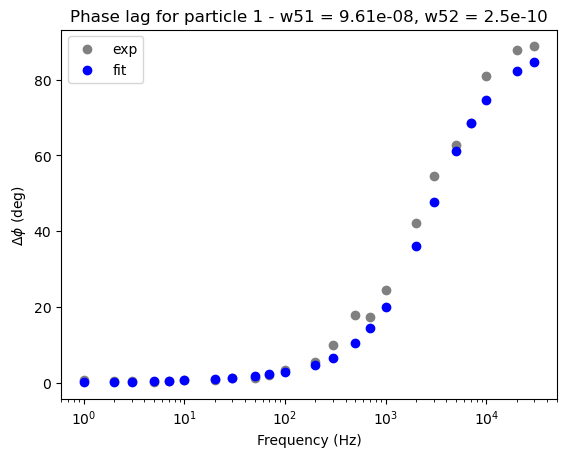

In [30]:
plt.scatter(frequencias_experimentais, adj_ph(fases_experimentais), color="gray", label="exp")
plt.scatter(frequencias_experimentais, adj_ph(fases_calculadas), color="blue", label="fit")
plt.xscale("log")
plt.ylabel("$\Delta \phi$ (deg)")
plt.xlabel("Frequency (Hz)")
plt.title(f"Phase lag for particle 1 - w51 = {W51}, w52 = {W52}")
plt.legend()
plt.show()

In [33]:
power = 4.6 # em W
w0 = (282e-9)*(1e2) # em cm
area = np.pi*w0**2
photon_energy = (6.62e-34*2.99e8)/977e-9

print(f"{(power/area):.2f}")

1841237206.94


In [34]:
np.log10(1841237206.94)

np.float64(9.265109742349171)